In [6]:
import numpy as np
import pandas as pd

np.random.seed(42)
N = 120000

data = pd.DataFrame({
    "user_id": np.random.randint(1, 5000, N),
    "transaction_amount": np.random.exponential(300, N),
    "transaction_time": np.random.randint(0, 24, N),
    "is_international": np.random.binomial(1, 0.15, N),
    "device_risk": np.random.uniform(0, 1, N),
    "location_risk": np.random.uniform(0, 1, N),
})

# -----------------------------
# Behavioral Feature Engineering
# -----------------------------

data["txn_velocity"] = data.groupby("user_id")["transaction_amount"].transform("count")

data["avg_user_amount"] = data.groupby("user_id")["transaction_amount"].transform("mean")

data["amount_deviation"] = (
    data["transaction_amount"] - data["avg_user_amount"]
) / (data["avg_user_amount"] + 1e-6)

data["night_flag"] = (data["transaction_time"].isin([0,1,2,3])).astype(int)

# -----------------------------
# Non-linear fraud generation
# -----------------------------

score = (
    0.015 * data["transaction_amount"] +
    1.2 * data["device_risk"] +
    1.0 * data["location_risk"] +
    0.8 * data["is_international"] +
    0.6 * data["night_flag"] +
    0.5 * (data["txn_velocity"] > 25).astype(int) +
    1.5 * np.abs(data["amount_deviation"])
)

prob = 1 / (1 + np.exp(-score))

data["is_fraud"] = (prob > np.quantile(prob, 0.97)).astype(int)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier
import joblib

# Features
X = data.drop(columns=["is_fraud", "user_id"])
y = data["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# 
# -----------------------------
model = GradientBoostingClassifier()

model.fit(X_train, y_train)

# -----------------------------
# Evaluation
# -----------------------------
preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:,1]

print("\n📊 Classification Report:\n")
print(classification_report(y_test, preds))

print("\n🔥 ROC AUC:", roc_auc_score(y_test, probs))

# Save model
joblib.dump(model, "xgb_fraud_model.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl")


📊 Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     23280
           1       0.97      0.96      0.97       720

    accuracy                           1.00     24000
   macro avg       0.99      0.98      0.98     24000
weighted avg       1.00      1.00      1.00     24000


🔥 ROC AUC: 0.9998943418289424


['feature_columns.pkl']

/Users/soumyabhaiya/Developer/deepLearning/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/2j/4kn8gjt52mv9jj17mp618zth0000gn/T/ipykernel_18900/2967150661.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample)


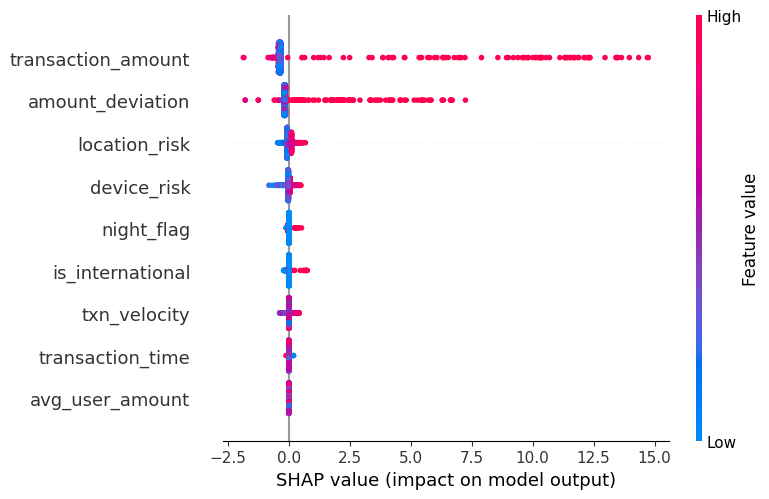

In [12]:
import shap
import matplotlib.pyplot as plt
import joblib

model = joblib.load("xgb_fraud_model.pkl")

X_test_sample = X_test.sample(2000, random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_sample)

# -----------------------------
# GLOBAL FEATURE IMPORTANCE
# -----------------------------
shap.summary_plot(shap_values, X_test_sample)

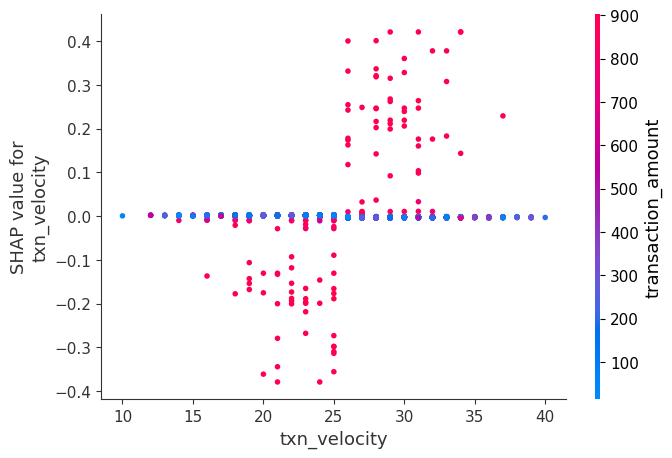

In [13]:
shap.dependence_plot("txn_velocity", shap_values, X_test_sample)

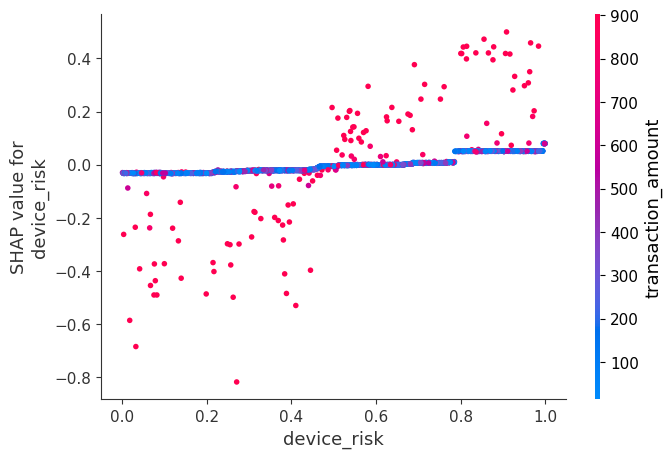

In [14]:
shap.dependence_plot("device_risk", shap_values, X_test_sample)